### 实验：使用GAN生成手写数字（MNIST）

本实验目标：
1. 理解生成对抗网络（GAN）的基本思想
2. 能够跑通一个完整的GAN训练流程
3. 学会调试网络结构与训练函数

说明：本实验默认使用 **CPU版本PyTorch**，GPU有条件可自行使用。

### 1. 安装与导入依赖

请确保以下代码可以正常运行，如报错请先完成环境配置。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch version:', torch.__version__)

Device: cuda
PyTorch version: 2.5.1+cu121


### 2. 数据集加载（MNIST）

MNIST 是一个经典的手写数字数据集，包含 0–9 共 10 类。

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print('Number of training samples:', len(train_dataset))

Number of training samples: 60000


### 3. 定义生成器（Generator）

生成器的作用：将随机噪声$z$映射为“看起来像真的”手写数字图像。这里定义了一个全连接网络，结构直观。

In [3]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.net(z)
        return out.view(-1, 1, 28, 28)

G = Generator()
print(G)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


### 4. 定义判别器（Discriminator）

判别器的作用：判断输入图像是真实样本还是生成样本。

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

D = Discriminator()
print(D)

Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### 5. 定义损失函数与优化器

In [5]:
criterion = nn.BCELoss()

lr=0.001
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

### 6. 训练 GAN

重点理解：
- 判别器的训练目标
- 生成器的训练目标

Epoch [1/20]  D_loss: 0.0000  G_loss: 12.4093
Epoch [2/20]  D_loss: 0.0000  G_loss: 13.7074
Epoch [3/20]  D_loss: 0.0000  G_loss: 14.3973
Epoch [4/20]  D_loss: 0.0000  G_loss: 13.2923
Epoch [5/20]  D_loss: 0.0000  G_loss: 14.9291
Epoch [6/20]  D_loss: 0.0000  G_loss: 15.7152
Epoch [7/20]  D_loss: 0.0000  G_loss: 16.5280
Epoch [8/20]  D_loss: 0.0000  G_loss: 17.1249
Epoch [9/20]  D_loss: 0.0000  G_loss: 17.3228
Epoch [10/20]  D_loss: 0.0000  G_loss: 17.2264
Epoch [11/20]  D_loss: 0.0000  G_loss: 18.3074
Epoch [12/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [13/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [14/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [15/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [16/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [17/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [18/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [19/20]  D_loss: 100.0000  G_loss: 0.0000
Epoch [20/20]  D_loss: 100.0000  G_loss: 0.0000


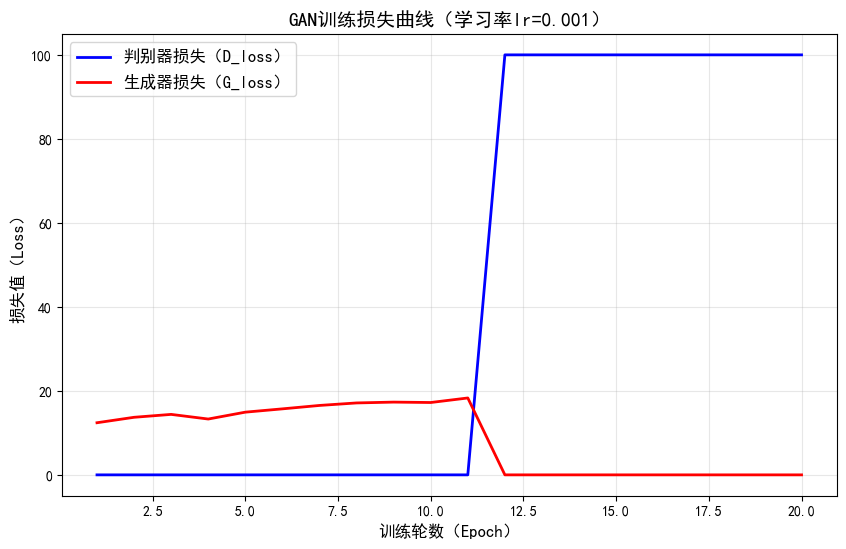

In [6]:
epochs = 20
noise_dim = 100

d_loss_list = []
g_loss_list = []

for epoch in range(epochs):
    for real_imgs, _ in train_loader:
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # ===== 训练判别器 =====
        optimizer_D.zero_grad()
        outputs = D(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, noise_dim)
        fake_imgs = G(z)
        outputs = D(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ===== 训练生成器 =====
        optimizer_G.zero_grad()
        outputs = D(fake_imgs)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()
        epoch_d_loss = d_loss.item()
        epoch_g_loss = g_loss.item()
        
     # 新增：将每一轮的损失值添加到列表中
    d_loss_list.append(epoch_d_loss)
    g_loss_list.append(epoch_g_loss)
    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")
# --------------------- 新增：绘制损失曲线 ---------------------
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
# 创建画布
plt.figure(figsize=(10, 6))
# 绘制D_loss曲线
plt.plot(range(1, epochs+1), d_loss_list, label='判别器损失（D_loss）', color='blue', linewidth=2)
# 绘制G_loss曲线
plt.plot(range(1, epochs+1), g_loss_list, label='生成器损失（G_loss）', color='red', linewidth=2)
# 添加标题和标签
plt.title(f'GAN训练损失曲线（学习率lr={lr}）', fontsize=14)
plt.xlabel('训练轮数（Epoch）', fontsize=12)
plt.ylabel('损失值（Loss）', fontsize=12)
# 添加网格
plt.grid(True, alpha=0.3)
# 添加图例
plt.legend(fontsize=12)
# 显示图像
plt.show()

### 7. 可视化生成结果

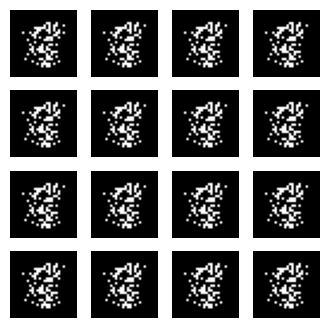

In [7]:
z = torch.randn(16, noise_dim)
fake_imgs = G(z).detach()
grid = fake_imgs.squeeze().numpy()
fig, axes = plt.subplots(4, 4, figsize=(4, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(grid[i], cmap='gray')
    ax.axis('off')
plt.show()

### 8.测试函数

In [8]:
import torch
import numpy as np
from torch.nn.functional import cosine_similarity

def evaluate_gan_simple(generator, noise_dim, num_samples=1000, device='cuda'):
    generator.eval()
    fake_imgs = []
    batch_size = 64
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            current_batch = min(batch_size, num_samples - len(fake_imgs))
            z = torch.randn(current_batch, noise_dim).to(device)
            img = generator(z)
            fake_imgs.append(img)
    
    fake_imgs = torch.cat(fake_imgs, dim=0)
    actual_num = fake_imgs.size(0)
    
    fake_imgs_np = fake_imgs.squeeze().cpu().numpy()
    pixel_variances = [np.var(img) for img in fake_imgs_np]
    pixel_variance = np.mean(pixel_variances)
    
    fake_imgs_flat = fake_imgs.view(actual_num, -1)
    sim_list = []
    sample_idx = np.random.choice(actual_num, min(200, actual_num), replace=False)
    for i in range(len(sample_idx)):
        for j in range(i+1, len(sample_idx)):
            sim = cosine_similarity(
                fake_imgs_flat[sample_idx[i]].unsqueeze(0),
                fake_imgs_flat[sample_idx[j]].unsqueeze(0)
            ).item()
            sim_list.append(sim)
    sim_mean = np.mean(sim_list)
    
    return pixel_variance, sim_mean

G = G.to(device)

pixel_var, sim_mean = evaluate_gan_simple(G, noise_dim=noise_dim, device=device)
print(f"平均像素方差={pixel_var:.4f}，余弦相似度均值={sim_mean:.4f}")

平均像素方差=0.4143，余弦相似度均值=0.9981


### 9. 思考与扩展

1. 如果增大 noise_dim，会发生什么？
2. 如果训练轮数增加，生成效果是否一定更好？
3. 能否将全连接GAN改为卷积GAN（DCGAN）？